# Synthetic mode recovery visualiser

Run independent adaptive-rank ensembles for the wave-only, exact spectral-infill background-only, and combined records, then use each ensemble's ceiling-median effective rank for its unperturbed DMD run. Save the requested input, phase-aligned matched, and native-phase spurious real-phasor snapshots as individual high-resolution Mollweide figures with four shared scale groups.

In [2]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

cwd = Path(os.getcwd()).resolve()
PROJECT_ROOT = next(
    path for path in (cwd, *cwd.parents)
    if (path / 'src' / 'msc_thesis').is_dir()
)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.msc_thesis.paths import *
from src.msc_thesis.synSetup import *
from src.msc_thesis.synUtils import *
from src.msc_thesis.synDMD import *
from src.msc_thesis.synFigures import *

['/home/elliott/projects/msc_thesis_project', '/home/elliott/miniforge3/envs/msc_thesis/lib/python311.zip', '/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11', '/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11/lib-dynload', '', '/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11/site-packages', '/home/elliott/projects/msc_thesis_project']
['/home/elliott/projects/msc_thesis_project', '/home/elliott/projects/msc_thesis_project', '/home/elliott/miniforge3/envs/msc_thesis/lib/python311.zip', '/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11', '/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11/lib-dynload', '', '/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11/site-packages', '/home/elliott/projects/msc_thesis_project']
['/home/elliott/projects/msc_thesis_project', '/home/elliott/projects/msc_thesis_project', '/home/elliott/projects/msc_thesis_project', '/home/elliott/miniforge3/envs/msc_thesis/lib/python311.zip', '/home/elliott/miniforge3/envs/msc_th

## Configuration

`visualisation_nmax` is shared by every record and snapshot. The wave-only, exact spectral-infill background-only, and combined cases each use their own perturbation ensemble and fractional SVD threshold to select the ceiling of their median effective rank for the corresponding unperturbed run.

In [4]:
all_mode_numbers = ['62', '6', '13', '48', '45', '1', '32']
mode_numbers = list(all_mode_numbers)

visualisation_nmax = 9
visualisation_n_ensemble = 100
spurious_target_period = 5.2

wave_only_setup = {
    'svd_rank': 0.999,
    'dmd_settings': {
        'dmd_type': 'exact',
        'hankel_flag': True,
        'embedding_d': 3,
        'weight_flag': True,
    },
}

background_only_setup = {
    'svd_rank': 0.999,
    'dmd_settings': {
        'dmd_type': 'exact',
        'hankel_flag': True,
        'embedding_d': 3,
        'weight_flag': True,
    },
}

waves_background_setup = {
    'svd_rank': 0.999,
    'dmd_settings': {
        'dmd_type': 'exact',
        'hankel_flag': True,
        'embedding_d': 6,
        'weight_flag': True,
    },
}

## Construct and recover modes

Construct the common synthetic suite, derive the exact background-only component as `background - resolved`, and run three independent adaptive-rank ensembles. Matched recovered phasors are taken from the resulting unperturbed runs and phase-aligned to their inputs without changing amplitude. The spurious mode is the unmatched feasible combined-record output nearest 5.2 years.

In [5]:
snapshot_entries, syn_suite_info, recovery_cases = (
    Build_Recovery_Visualisation_Data(
        mode_numbers=mode_numbers,
        nmax=visualisation_nmax,
        wave_only_setup=wave_only_setup,
        background_only_setup=background_only_setup,
        waves_background_setup=waves_background_setup,
        n_ensemble=visualisation_n_ensemble,
        spurious_target_period=spurious_target_period,
    )
)

/home/elliott/projects/msc_thesis_project/src/msc_thesis/synDMD.py:641: RuntimeWarning: divide by zero encountered in scalar divide
  period = 2.0 * np.pi / np.abs(eig.imag)
/home/elliott/projects/msc_thesis_project/src/msc_thesis/synDMD.py:1428: RuntimeWarning: divide by zero encountered in scalar divide
  period = 2.0 * np.pi / np.abs(eig.imag)
/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11/site-packages/pydmd/snapshots.py:73: UserWarning: Input data condition number 1468051.1712387144. Consider preprocessing data, passing in augmented data
matrix, or regularization methods.
  warnings.warn(
/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1213: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1592: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdim

## Plot recovered snapshots

Save each requested real-phasor Mollweide snapshot individually as a 600-DPI PNG and PDF under `results/recovery_visualisation`. Coordinate labels, grids, and colour bars are omitted. The four explicitly defined snapshot sets share symmetric colour limits based on the maximum absolute real value within each set.

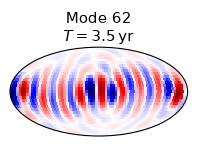

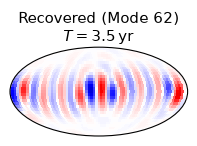

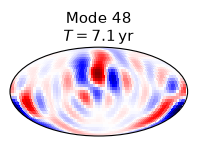

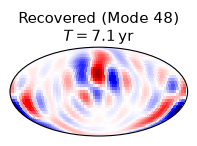

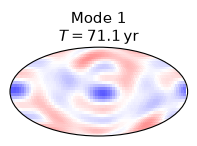

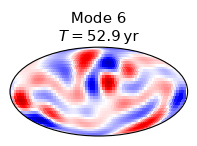

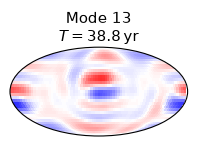

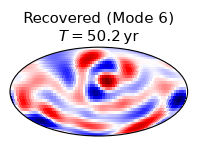

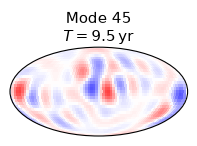

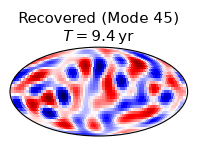

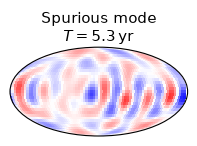

In [6]:
snapshot_figures, saved_snapshot_paths, snapshot_group_limits = (
    Save_Recovery_Visualisation_Snapshots(
        snapshot_entries,
        output_dir=RESULT_DIR / 'recovery_visualisation',
        figure_width=text_width / 4,
        font_size=11,
    )
)
plt.show()

In [7]:
# Audit each independent ensemble-derived rank and selected output.
for case_key, case_output in recovery_cases.items():
    record_result = case_output['results'][case_output['record_key']]
    rank_selection = record_result['rank_selection']
    print(
        f"{case_key}: threshold={rank_selection['ensemble_svd_rank']}, "
        f"median effective rank="
        f"{rank_selection['ensemble_effective_rank_median']:.1f}, "
        f"unperturbed rank={rank_selection['unperturbed_rank_used']}"
    )

spurious_entry = snapshot_entries[
    'waves_background_spurious_mode_5p2yr'
]
print(
    f"Selected spurious output index "
    f"{spurious_entry['recovered_index']} at "
    f"T={spurious_entry['period']:.3f} yr."
)
print(f"Saved {2 * len(saved_snapshot_paths)} files.")

wave_only: threshold=0.999, median effective rank=11.0, unperturbed rank=11
background_only: threshold=0.999, median effective rank=15.0, unperturbed rank=15
waves_background: threshold=0.999, median effective rank=13.0, unperturbed rank=13
Selected spurious output index 1 at T=5.289 yr.
Saved 22 files.
